In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("C:\\Users\\User\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

# Dataset Overview
print("Dataset Shape:", df.shape)
print("\nDataset Info:\n")
print(df.info())
print("\nNumerical Summary:\n")
print(df.describe())
print("\nCategorical Summary:\n")
print(df.describe(include='object'))

# Identify Column Types
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)

# Missing Values and Duplicates
print("Missing Values:\n")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Fix TotalCharges datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

# New customers (tenure=0) have no charges yet; fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Remove customerID column before any encoding
df.drop('customerID', axis=1, inplace=True)

# Encode target variable with a simple binary map (no LabelEncoder needed)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Update column type lists after dropping customerID
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ── Preprocessing Pipeline ──────────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 70/30 stratified split — preserves churn class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} | Test set size: {X_test.shape[0]}")
print(f"Churn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

# Shared preprocessor: StandardScaler for numerics, OHE for categoricals.
# Fitting happens inside each model's pipeline, so only training data
# is ever seen by the scaler/encoder — no data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)


Dataset Shape: (7043, 21)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  

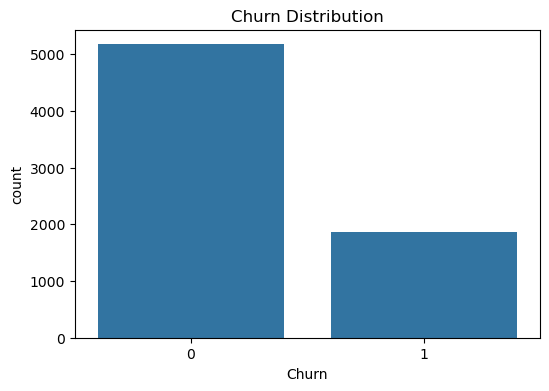

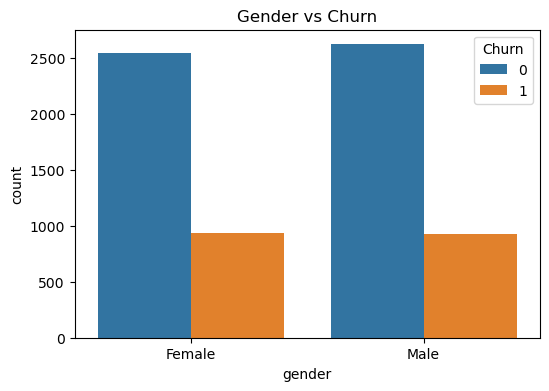

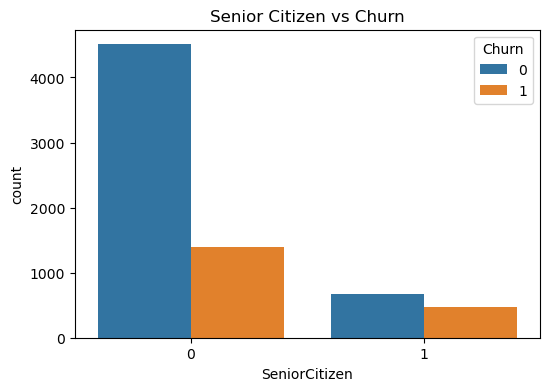

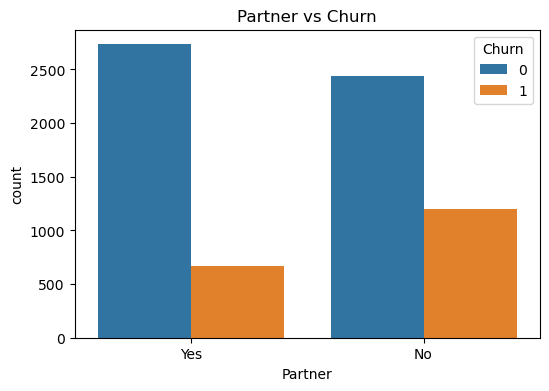

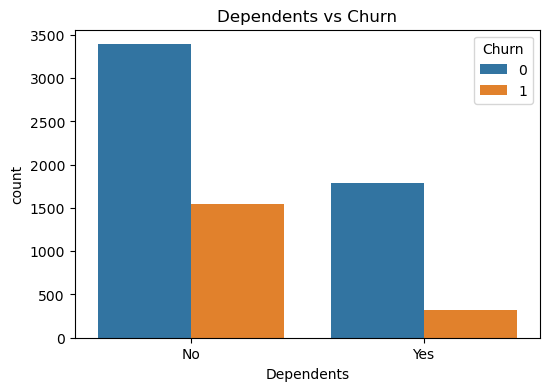

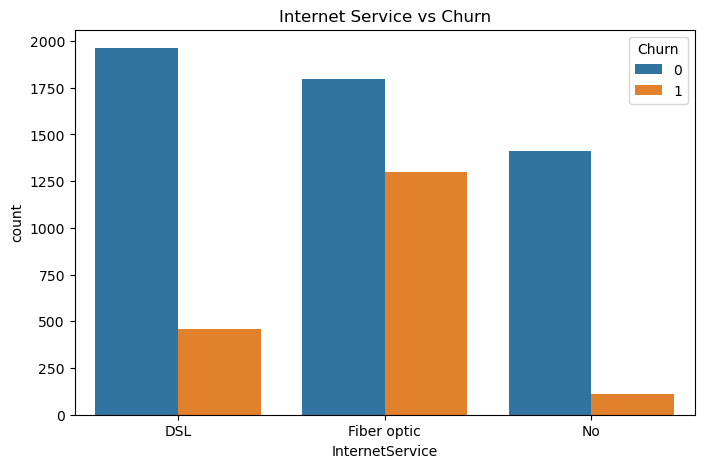

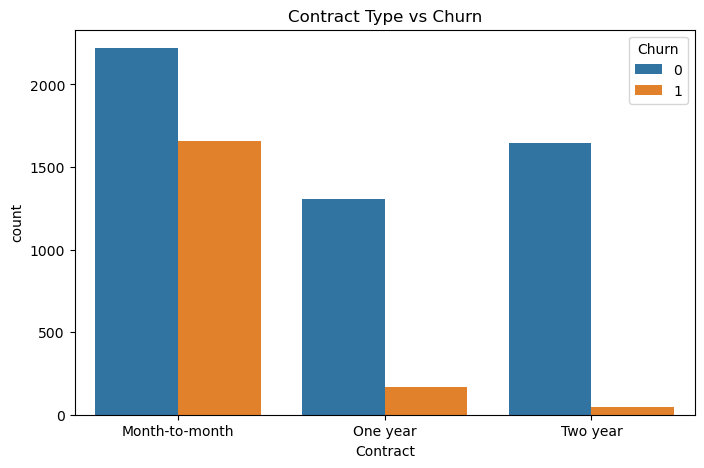

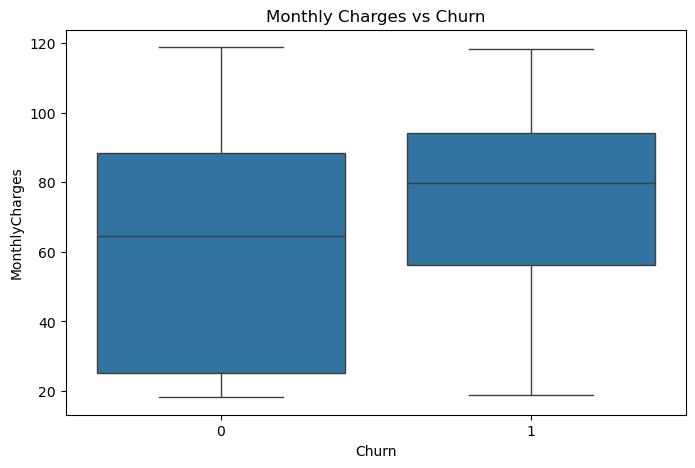

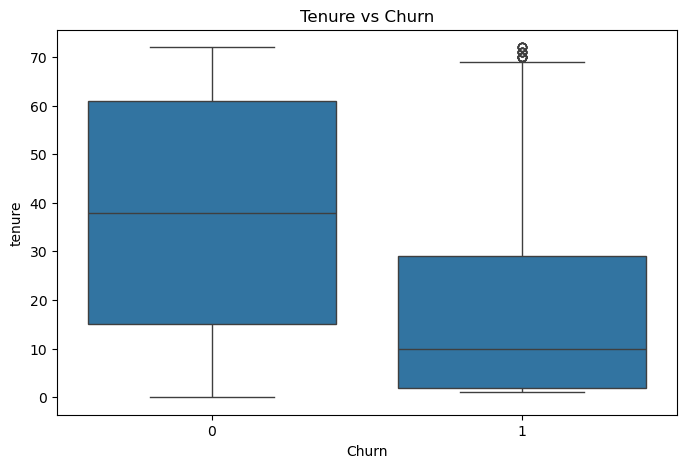

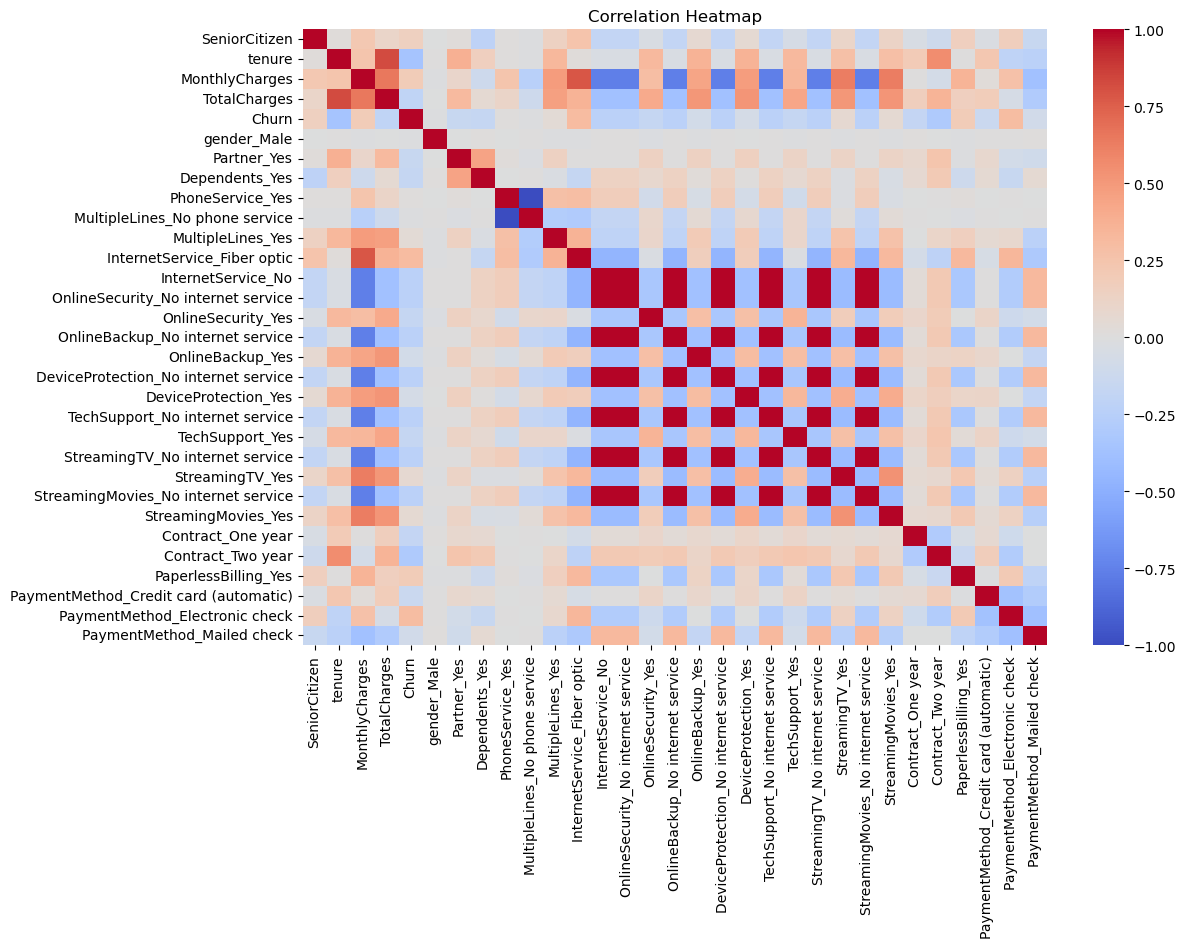

In [2]:
# Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")

plt.show()

# Gender vs Churn

plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

# Senior Citizen vs Churn

plt.figure(figsize=(6,4))

sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.show()

# Partner vs Churn

plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    hue='Churn',
    data=df
)

plt.title("Partner vs Churn")

plt.show()

# Dependents vs Churn
plt.figure(figsize=(6,4))

sns.countplot(
    x='Dependents',
    hue='Churn',
    data=df
)

plt.title("Dependents vs Churn")

plt.show()

# Internet Service vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

# Contract Type vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()


# Monthly Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

# Tenure vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Tenure vs Churn")

plt.show()


# Create encoded DataFrame for correlation heatmap (visualisation only)
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


Logistic Regression
--------------------------------------------------
Accuracy: 0.8064363464268812
Precision: 0.6603375527426161
Recall: 0.5579322638146168
F1 Score: 0.6048309178743961
ROC-AUC: 0.8441416515059632

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.66      0.56      0.60       561

    accuracy                           0.81      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113


Random Forest
--------------------------------------------------
Accuracy: 0.7841930903928065
Precision: 0.6235294117647059
Recall: 0.47237076648841353
F1 Score: 0.537525354969574
ROC-AUC: 0.8159387231931198

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1552
           1       0.62      0.47      0.54       561

    accuracy                       

<Figure size 600x600 with 0 Axes>

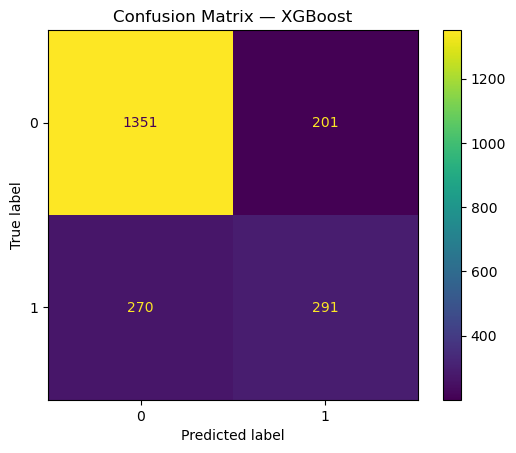

<Figure size 800x600 with 0 Axes>

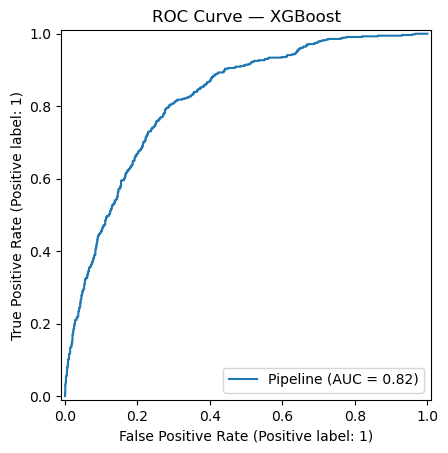

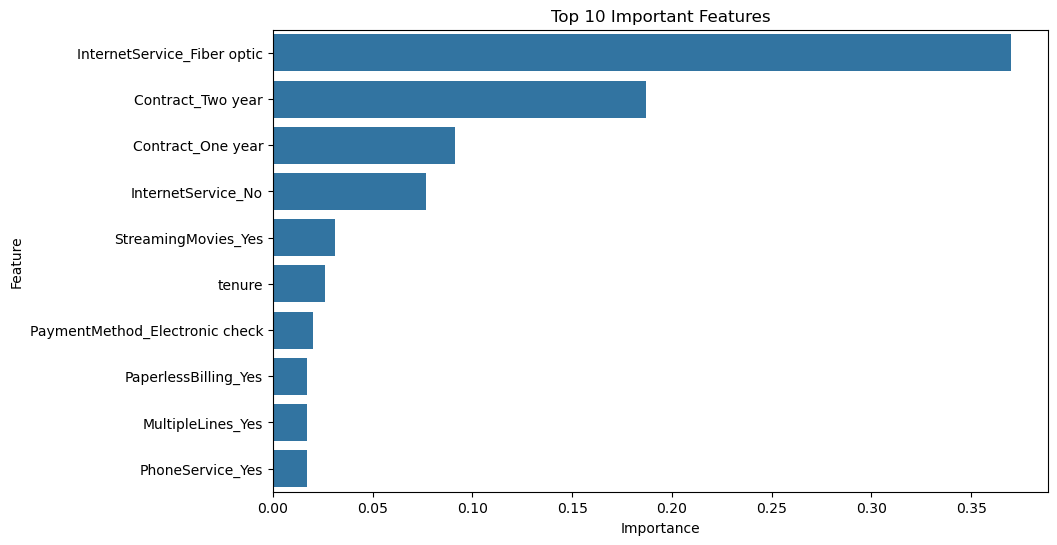

In [3]:
# Feature Engineering
# Train Models using sklearn Pipelines (preprocessor + classifier)
# The preprocessor is fitted only on X_train inside each pipeline,
# which prevents any data leakage to the test set.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("-" * 50)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(xgb_pipeline, X_test, y_test)
plt.title("Confusion Matrix — XGBoost")
plt.show()

# ROC Curve (with numeric AUC printed above)

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test)
plt.title("ROC Curve — XGBoost")
plt.show()

# Feature Importance

xgb_classifier = xgb_pipeline.named_steps['classifier']
ohe_cols = (
    xgb_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)
all_feature_names = list(numerical_cols) + list(ohe_cols)

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

# Plot Top Features

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()


In [4]:
# Predict churn for all customers using the trained XGBoost pipeline
df['PredictedChurn'] = xgb_pipeline.predict(X)

# Revenue Loss Calculation (based on MODEL predictions, not ground-truth labels)

predicted_churners = df[df['PredictedChurn'] == 1]

total_revenue_loss = predicted_churners['MonthlyCharges'].sum()

print("Estimated Monthly Revenue at Risk: $", round(total_revenue_loss, 2))

# High-Risk High-Value Customers
# (assigned BEFORE printing — fixes the previous NameError)

df['HighValueCustomer'] = np.where(
    df['MonthlyCharges'] > df['MonthlyCharges'].median(),
    1,
    0
)

high_risk_high_value = df[
    (df['PredictedChurn'] == 1)
    &
    (df['HighValueCustomer'] == 1)
]

print(f"\nNumber of High-Risk High-Value customers found: {len(high_risk_high_value)}")
print(high_risk_high_value[['MonthlyCharges', 'tenure', 'Contract']].head())
print(high_risk_high_value.head())
print("\nCount:", len(high_risk_high_value))

# Retention Strategy Simulation

discount_cost_per_customer = 20
retention_success_rate = 0.30    # realistic campaign conversion rate
customers_to_retain = len(high_risk_high_value)

retention_cost = discount_cost_per_customer * customers_to_retain

saved_revenue = (
    high_risk_high_value['MonthlyCharges'].mean()
    * customers_to_retain
    * retention_success_rate
)

net_gain = saved_revenue - retention_cost

print("\nRetention Cost: $", retention_cost)
print(f"Saved Revenue (at {retention_success_rate:.0%} success rate): $", round(saved_revenue, 2))
print("Net Gain: $", round(net_gain, 2))

# Break-Even Point
# How many customers must be retained to cover the full retention spend?

avg_monthly_charge = high_risk_high_value['MonthlyCharges'].mean()
breakeven_customers = retention_cost / avg_monthly_charge
breakeven_rate = breakeven_customers / customers_to_retain

print(f"\nBreak-Even Analysis")
print(f"  Avg Monthly Charge (high-risk/high-value): ${avg_monthly_charge:.2f}")
print(f"  Customers needed to cover retention cost:  {breakeven_customers:.1f} of {customers_to_retain}")
print(f"  Required retention success rate:            {breakeven_rate:.1%}")


Estimated Monthly Revenue at Risk: $ 133986.15

Number of High-Risk High-Value customers found: 1245
    MonthlyCharges  tenure        Contract
4            70.70       2  Month-to-month
5            99.65       8  Month-to-month
6            89.10      22  Month-to-month
8           104.80      28  Month-to-month
13          103.70      49  Month-to-month
    gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
4   Female              0      No         No       2          Yes   
5   Female              0      No         No       8          Yes   
6     Male              0      No        Yes      22          Yes   
8   Female              0     Yes         No      28          Yes   
13    Male              0      No         No      49          Yes   

   MultipleLines InternetService OnlineSecurity OnlineBackup  ... StreamingTV  \
4             No     Fiber optic             No           No  ...          No   
5            Yes     Fiber optic             No           No  ..